In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
from matplotlib.colors import to_hex
from scipy.optimize import linear_sum_assignment

sys.path.append('../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS      = 5
NUM_EPOCHS  = 200
VALIDATE_EVERY = 50
BATCH_SIZE  = 4096
LATENT_DIM  = 16
PATIENCE    = 20
RESULTS_DIR = "results/benchmarking"
N_CLUSTERS  = 10

# Metrics tracked for scoring and box plots
METRIC_COLS = [
    'cf_ate_pearson_r',
    'cluster_f1',
    'cluster_ari',
    'cluster_ami',
    'cluster_silhouette',
    'cluster_linear_probe',
    'cluster_knn_purity',
]

# (model_key, display_name, method-specific kwargs)
METHODS = [
    ("vae", "sherlock", {
        "l0_lambda": 8.5,
        "ce_lambda": 20.0,
        "n_epochs_kl_warmup": 300,
        "n_epochs_l0_warmup": 350,
        "tau_end": 0.25,
        "rank": 8,
    }, 600), # total epochs
    
    ("svae",          "sVAE",          {"sparse_mask_penalty": 10.0},  NUM_EPOCHS),
    ("cvae",          "cVAE",          {},  NUM_EPOCHS),
    ("contrastivevi", "contrastiveVI", {},  NUM_EPOCHS),
    ("scgen",         "scgen",         {},  NUM_EPOCHS),
]

os.makedirs(f"{RESULTS_DIR}/models",   exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/figures",  exist_ok=True)

print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/benchmarking


In [4]:
import inspect
run_globals = slk.tl.run_single.__globals__
VAE_obj = run_globals.get('VAE')
VAETrainer_obj = run_globals.get('VAETrainer')

print("Valid VAE Model params:", list(inspect.signature(VAE_obj.__init__).parameters.keys()) if VAE_obj else [])
print("Valid VAETrainer params:", list(inspect.signature(VAETrainer_obj.__init__).parameters.keys()) if VAETrainer_obj else [])

Valid VAE Model params: ['self', 'input_dim', 'latent_dim', 'perturbs', 'conds', 'tau', 'l0_lambda', 'l1_lambda', 'l2_lambda', 'H_lambda', 'ce_lambda', 'ntc_lambda', 'pert_lambda', 'cov_lambda', 'gate_row_repulsion_lambda', 'gate_init_p', 'rank', 'use_conditions', 'shift', 'use_synergy', 'synergy_rank', 'use_de_align_loss', 'de_align_lambda', 'treat_effect_map', 'combinatorial', 'z_var']
Valid VAETrainer params: ['self', 'vae', 'dataloader', 'treat_effect', 'adata', 'lr', 'num_epochs', 'validate_every', 'verbose', 'device', 'seed', 'non_blocking_copy', 'tau_init', 'tau_end', 'tau_anneal_steps', 'patience', 'n_epochs_kl_warmup', 'n_epochs_l0_warmup']


## Data loading and ground-truth ATE

In [5]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|████████████████████████████████████████████████████████████████████████| 681/681 [00:10<00:00, 64.85it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for clustering evaluation

In [6]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Benchmark loop

Each method is trained `N_RUNS` times independently. The best-scoring run
per method is saved to `results/models/`. Metrics are computed after training
using the proper counterfactual ATE protocol; the clustering cut is chosen
automatically via the elbow method.

In [9]:
import gc
import os
import torch
import pandas as pd
import numpy as np
import shutil

# Path to store aggregate metrics checkpoint
METRICS_CSV = f"{RESULTS_DIR}/benchmarking_metrics.csv"

# 1. Load existing metrics from disk if the notebook previously crashed
if os.path.exists(METRICS_CSV):
    print(f"Found existing metrics checkpoint. Loading {METRICS_CSV}...")
    results_df = pd.read_csv(METRICS_CSV)
    records = results_df.to_dict(orient='records')
else:
    records = []

# Global dictionary tracking to mimic your original architecture for later cells
best_run_score = {}

for model_key, display_name, extra_kwargs, EPOCHS in METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs)\n{'='*60}")
    
    best_run_idx = -1
    best_run_score[display_name] = -np.inf

    for run in range(N_RUNS):
        print(f"\n  -- {display_name} run {run + 1}/{N_RUNS} --")
        
        # Unique file path for this specific run's checkpoint
        run_save_path = f"{RESULTS_DIR}/models/{display_name}_run_{run}.pth"
        
        # Check if this run is already fully completed on disk
        already_run = any(r['method'] == display_name and r['run'] == run for r in records)
        
        if already_run and os.path.exists(run_save_path):
            print(f"    -> [RESUMING] Found completed results for run {run}. Skipping training.")
            # Extract metrics from our loaded records list
            metrics = next(r for r in records if r['method'] == display_name and r['run'] == run)
        else:
            # Fresh execution if missing or incomplete
            out = slk.tl.run(
                data,
                model=model_key,
                batch_size=BATCH_SIZE,
                num_epochs=EPOCHS,
                device=DEVICE,
                latent_dim=LATENT_DIM,
                patience=PATIENCE,
                validate_every=VALIDATE_EVERY,
                seed=run,
                **extra_kwargs,
            )
            model = out['model']

            metrics = slk.tl.evaluate_model(
                model,
                data,
                treat_effect_adata,
                pathway_df_indexed,
                all_genes_filtered,
                n_clusters=N_CLUSTERS,
                device=DEVICE,
                use_rho=False,
            )

            # Checkpoint individual model run immediately to disk
            slk.tl.save_results(out, run_save_path)

            metrics['method'] = display_name
            metrics['run']    = run
            
            # Cleanly update records (prevents duplicated records if restarted mid-run)
            records = [r for r in records if not (r['method'] == display_name and r['run'] == run)]
            records.append(metrics)
            
            # Checkpoint metrics table to CSV immediately
            pd.DataFrame(records).to_csv(METRICS_CSV, index=False)

        # Track which run was the best mathematically based on the score
        run_avg = float(metrics['cf_ate_pearson_r'])
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_idx = run

        # Print metrics to the terminal
        for k, v in metrics.items():
            if k not in ('method', 'run'):
                val_str = f"{v:.4f}" if np.isfinite(float(v)) else "NaN"
                print(f"    {k:30s} = {val_str}")
        
        # CRITICAL: Delete active variables and clear GPU cache to avoid OOM crashes
        if 'out' in locals(): del out
        if 'model' in locals(): del model
        torch.cuda.empty_cache()
        gc.collect()

    # FIX APPLIED HERE: Direct disk copy instead of using the problematic package functions
    if best_run_idx != -1:
        best_run_path = f"{RESULTS_DIR}/models/{display_name}_run_{best_run_idx}.pth"
        final_save_path = f"{RESULTS_DIR}/models/{display_name}_best.pth"
        
        print(f"\n  Isolating best run ({best_run_idx + 1}) for {display_name}...")
        shutil.copy(best_run_path, final_save_path)
        print(f"  Saved best {display_name} model → {final_save_path}")

results_df = pd.DataFrame(records)
print("\nDone.")

Found existing metrics checkpoint. Loading results/benchmarking/benchmarking_metrics.csv...

sherlock  (5 runs)

  -- sherlock run 1/5 --
    -> [RESUMING] Found completed results for run 0. Skipping training.
    cf_ate_pearson_r               = 0.6017
    cluster_accuracy               = 0.9881
    cluster_precision              = 0.9920
    cluster_recall                 = 0.9888
    cluster_f1                     = 0.9902
    cluster_ari                    = 0.7941
    cluster_ami                    = 0.9152
    cluster_homogeneity            = 0.9777
    cluster_completeness           = 0.8677
    cluster_v_measure              = 0.9194
    cluster_silhouette             = 0.4007
    cluster_purity                 = 0.9881
    cluster_knn_purity             = 0.9845
    cluster_linear_probe           = 0.9940
    rho_z_pearson_r                = 0.6944

  -- sherlock run 2/5 --
    -> [RESUMING] Found completed results for run 1. Skipping training.
    cf_ate_pearson_r            

sVAE:   0%|                                                                            | 0/200 [00:00<?, ?it/s…

    cf_ate_pearson_r               = 0.2662
    cluster_accuracy               = 0.9851
    cluster_precision              = 0.9859
    cluster_recall                 = 0.9809
    cluster_f1                     = 0.9828
    cluster_ari                    = 0.8176
    cluster_ami                    = 0.9159
    cluster_homogeneity            = 0.9749
    cluster_completeness           = 0.8712
    cluster_v_measure              = 0.9201
    cluster_silhouette             = 0.3526
    cluster_purity                 = 0.9851
    cluster_knn_purity             = 0.9731
    cluster_linear_probe           = 0.9881
    rho_z_pearson_r                = 0.6472

  -- sVAE run 2/5 --


sVAE:   0%|                                                                            | 0/200 [00:00<?, ?it/s…

    cf_ate_pearson_r               = 0.2712
    cluster_accuracy               = 0.9552
    cluster_precision              = 0.9713
    cluster_recall                 = 0.9528
    cluster_f1                     = 0.9613
    cluster_ari                    = 0.8440
    cluster_ami                    = 0.8927
    cluster_homogeneity            = 0.9412
    cluster_completeness           = 0.8589
    cluster_v_measure              = 0.8982
    cluster_silhouette             = 0.3308
    cluster_purity                 = 0.9552
    cluster_knn_purity             = 0.9534
    cluster_linear_probe           = 0.9940
    rho_z_pearson_r                = 0.7159

  -- sVAE run 3/5 --


...

    cf_ate_pearson_r               = 0.7766
    cluster_accuracy               = 0.9164
    cluster_precision              = 0.9030
    cluster_recall                 = 0.8749
    cluster_f1                     = 0.8656
    cluster_ari                    = 0.8638
    cluster_ami                    = 0.8622
    cluster_homogeneity            = 0.8986
    cluster_completeness           = 0.8420
    cluster_v_measure              = 0.8694
    cluster_silhouette             = 0.2154
    cluster_purity                 = 0.9164
    cluster_knn_purity             = 0.9594
    cluster_linear_probe           = 0.9910
    rho_z_pearson_r                = 1.0000

  -- scgen run 4/5 --


scGEN:   0%|                                                                           | 0/200 [00:00<?, ?it/s…

    cf_ate_pearson_r               = 0.7675
    cluster_accuracy               = 0.9104
    cluster_precision              = 0.8980
    cluster_recall                 = 0.8669
    cluster_f1                     = 0.8585
    cluster_ari                    = 0.8835
    cluster_ami                    = 0.8732
    cluster_homogeneity            = 0.8987
    cluster_completeness           = 0.8617
    cluster_v_measure              = 0.8798
    cluster_silhouette             = 0.2293
    cluster_purity                 = 0.9104
    cluster_knn_purity             = 0.9576
    cluster_linear_probe           = 0.9791
    rho_z_pearson_r                = 1.0000

  -- scgen run 5/5 --


scGEN:   0%|                                                                           | 0/200 [00:00<?, ?it/s…

    cf_ate_pearson_r               = 0.7749
    cluster_accuracy               = 0.8687
    cluster_precision              = 0.8101
    cluster_recall                 = 0.8091
    cluster_f1                     = 0.8024
    cluster_ari                    = 0.8443
    cluster_ami                    = 0.8255
    cluster_homogeneity            = 0.8604
    cluster_completeness           = 0.8103
    cluster_v_measure              = 0.8346
    cluster_silhouette             = 0.2279
    cluster_purity                 = 0.8896
    cluster_knn_purity             = 0.9564
    cluster_linear_probe           = 0.9821
    rho_z_pearson_r                = 1.0000

  Isolating best run (3) for scgen...
  Saved best scgen model → results/benchmarking/models/scgen_best.pth

Done.


In [ ]:
if best_run_idx != -1:
    best_run_path = f"{RESULTS_DIR}/models/{display_name}_run_{best_run_idx}.pth"
    final_save_path = f"{RESULTS_DIR}/models/{display_name}_best.pth"
    
    print(f"\n  Isolating best run ({best_run_idx + 1}) for {display_name}...")
    best_out = slk.tl.load_results(best_run_path)
    slk.tl.save_results(best_out, final_save_path)
    print(f"  Saved best {display_name} model → {final_save_path}")
    
    del best_out
    torch.cuda.empty_cache()
    gc.collect()

results_df = pd.DataFrame(records)
print("\nDone.")

In [ ]:
records         = []
best_run_out    = {}   # method → out dict of best single run
best_run_model  = {}   # method → model of best single run
best_run_score  = {}   # method → avg metric score of best single run

for model_key, display_name, extra_kwargs, EPOCHS, in METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs)\n{'='*60}")
    best_run_score[display_name] = -np.inf

    for run in range(N_RUNS):
        print(f"\n  -- {display_name} run {run + 1}/{N_RUNS} --")

        out = slk.tl.run(
            data,
            model=model_key,
            batch_size=BATCH_SIZE,
            num_epochs=EPOCHS,
            device=DEVICE,
            latent_dim=LATENT_DIM,
            patience=PATIENCE,
            validate_every=VALIDATE_EVERY,
            seed=run,
            **extra_kwargs,
        )
        model = out['model']

        metrics = slk.tl.evaluate_model(
            model,
            data,
            treat_effect_adata,
            pathway_df_indexed,
            all_genes_filtered,
            n_clusters=N_CLUSTERS,
            device=DEVICE,
            use_rho=False,
        )

        # Track best run for this method
        run_avg = float(metrics['cf_ate_pearson_r'])
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_out[display_name]   = out
            best_run_model[display_name] = model

        metrics['method'] = display_name
        metrics['run']    = run
        records.append(metrics)

        for k, v in metrics.items():
            if k not in ('method', 'run'):
                val_str = f"{v:.4f}" if np.isfinite(float(v)) else "NaN"
                print(f"    {k:30s} = {val_str}")

    # Save best run model for this method
    save_path = f"{RESULTS_DIR}/models/{display_name}_best.pth"
    slk.tl.save_results(best_run_out[display_name], save_path)
    print(f"\n  Saved best {display_name} model → {save_path}")

results_df = pd.DataFrame(records)
print("\nDone.")


sherlock  (5 runs)

  -- sherlock run 1/5 --
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

    cf_ate_pearson_r               = 0.5965
    cluster_accuracy               = 0.9970
    cluster_precision              = 0.9977
    cluster_recall                 = 0.9987
    cluster_f1                     = 0.9982
    cluster_ari                    = 0.8687
    cluster_ami                    = 0.9464
    cluster_homogeneity            = 0.9966
    cluster_completeness           = 0.9059
    cluster_v_measure              = 0.9491
    cluster_silhouette             = 0.4025
    cluster_purity                 = 0.9970
    cluster_knn_purity             = 0.9851
    cluster_linear_probe           = 0.9910
    rho_z_pearson_r                = 0.6945

  -- sherlock run 2/5 --
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

    cf_ate_pearson_r               = 0.5661
    cluster_accuracy               = 0.9881
    cluster_precision              = 0.9871
    cluster_recall                 = 0.9916
    cluster_f1                     = 0.9891
    cluster_ari                    = 0.7928
    cluster_ami                    = 0.9121
    cluster_homogeneity            = 0.9800
    cluster_completeness           = 0.8608
    cluster_v_measure              = 0.9166
    cluster_silhouette             = 0.3926
    cluster_purity                 = 0.9881
    cluster_knn_purity             = 0.9815
    cluster_linear_probe           = 0.9910
    rho_z_pearson_r                = 0.6831

  -- sherlock run 3/5 --
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

    cf_ate_pearson_r               = 0.5734
    cluster_accuracy               = 0.9881
    cluster_precision              = 0.9912
    cluster_recall                 = 0.9818
    cluster_f1                     = 0.9859
    cluster_ari                    = 0.9457
    cluster_ami                    = 0.9476
    cluster_homogeneity            = 0.9789
    cluster_completeness           = 0.9234
    cluster_v_measure              = 0.9503
    cluster_silhouette             = 0.3994
    cluster_purity                 = 0.9881
    cluster_knn_purity             = 0.9863
    cluster_linear_probe           = 0.9940
    rho_z_pearson_r                = 0.6643

  -- sherlock run 4/5 --
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

## Results summary

In [10]:
summary = (
    results_df
    .groupby('method')[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
# Preserve METHODS order
method_order = [m[1] for m in METHODS]
summary = summary.reindex([m for m in method_order if m in summary.index])
print(summary.to_string())

              cf_ate_pearson_r         cluster_f1         cluster_ari         cluster_ami         cluster_silhouette         cluster_linear_probe         cluster_knn_purity        
                          mean     std       mean     std        mean     std        mean     std               mean     std                 mean     std               mean     std
method                                                                                                                                                                              
sherlock                0.5889  0.0225     0.9893  0.0077      0.8852  0.0870      0.9364  0.0261             0.3997  0.0053               0.9940  0.0021             0.9835  0.0023
sVAE                    0.2701  0.0067     0.8779  0.1336      0.7377  0.1516      0.8320  0.1268             0.3278  0.0411               0.9899  0.0034             0.9508  0.0304
cVAE                    0.4212  0.0282     0.9019  0.0428      0.7129  0.0392      0.8343  0.02

## Box plots

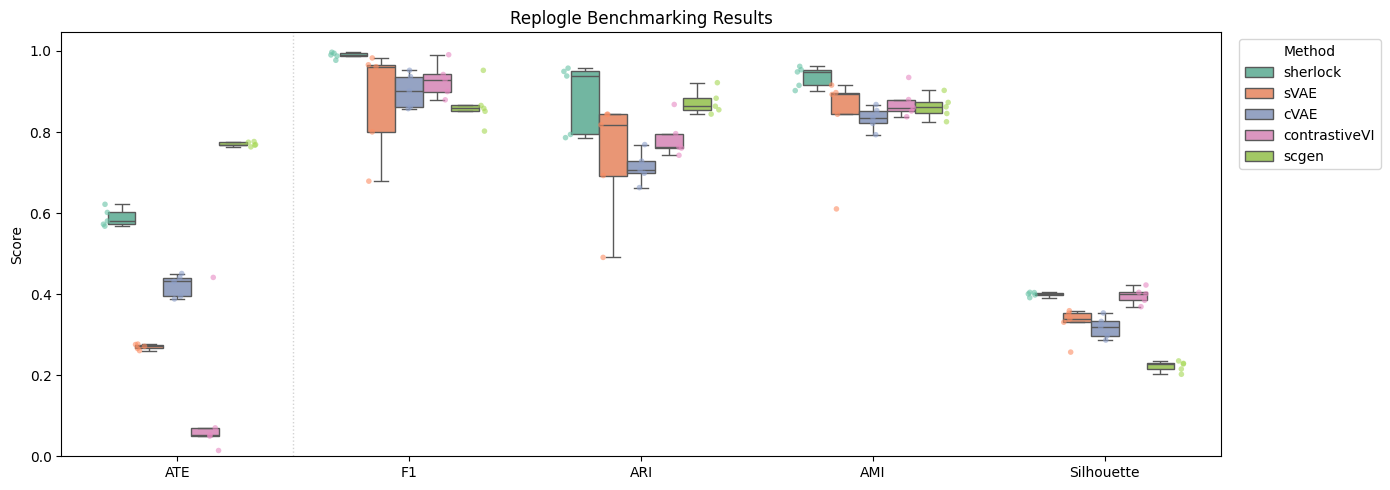

In [11]:
label_map = {
    'cf_ate_pearson_r':   'ATE',
    'cluster_f1':         'F1',
    'cluster_ari':        'ARI',
    'cluster_ami':        'AMI',
    'cluster_silhouette': 'Silhouette',
    # 'cluster_linear_probe': 'Linear\nProbe',
    # 'cluster_knn_purity': 'kNN\nPurity',
}

METRIC_COLS_PLOT = [
    m for m in METRIC_COLS
    if m not in ['cluster_linear_probe', 'cluster_knn_purity']
]

method_order = [m[1] for m in METHODS]

df_melted = results_df.melt(
    id_vars='method', value_vars=METRIC_COLS_PLOT, var_name='metric', value_name='value'
)
df_melted['metric_label'] = pd.Categorical(
    df_melted['metric'].map(label_map),
    categories=[label_map[m] for m in METRIC_COLS_PLOT],
    ordered=True,
)
df_melted['method'] = pd.Categorical(
    df_melted['method'], categories=method_order, ordered=True
)
df_melted['value'] = df_melted['value'].clip(lower=0)

fig, ax = plt.subplots(figsize=(14, 5))

sns.boxplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    palette='Set2',
    width=0.6,
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    palette='Set2',
    dodge=True,
    size=4,
    alpha=0.6,
    legend=False,
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title('Replogle Benchmarking Results')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(bottom=0)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Separator between ATE and clustering metrics
ax.axvline(0.5, color='lightgray', linewidth=1.0, linestyle=':')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_boxplot.png', bbox_inches='tight')
plt.show()

## Per-method best models — latent space UMAPs

For each method, re-eval the best run, compute UMAP on non-NTC cells, cluster the
pathway-gene subset of z_corr (maxclust), align predicted clusters to true pathways
via Hungarian matching, and save the figure.

In [13]:
import os

# Reconstruct the best_run_model dictionary from our saved disk checkpoints
best_run_model = {}

for model_key, display_name, *rest in METHODS:
    final_save_path = f"{RESULTS_DIR}/models/{display_name}_best.pth"
    
    if os.path.exists(final_save_path):
        print(f"Loading best model for {display_name}...")
        # slk.tl.load_results loads the raw trained VAE model from disk
        best_run_model[display_name] = slk.tl.load_results(final_save_path)
    else:
        print(f"Skipping {display_name}: No saved best model found at {final_save_path}")

print(f"\nSuccessfully loaded {len(best_run_model)} models into 'best_run_model'!")

Loading best model for sherlock...
Loading best model for sVAE...
Loading best model for cVAE...
Loading best model for contrastiveVI...
Loading best model for scgen...

Successfully loaded 5 models into 'best_run_model'!



Generating figure for best sherlock model


/var/tmp/ipykernel_3570/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sherlock_best_umap.png


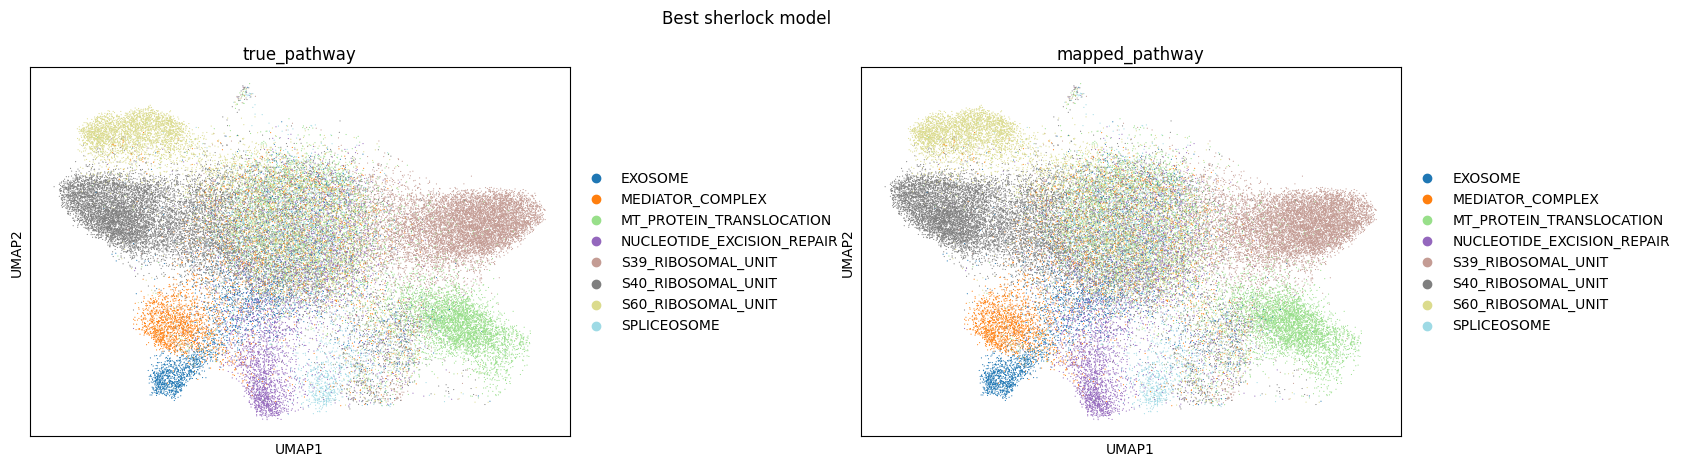


Generating figure for best sVAE model


/var/tmp/ipykernel_3570/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sVAE_best_umap.png


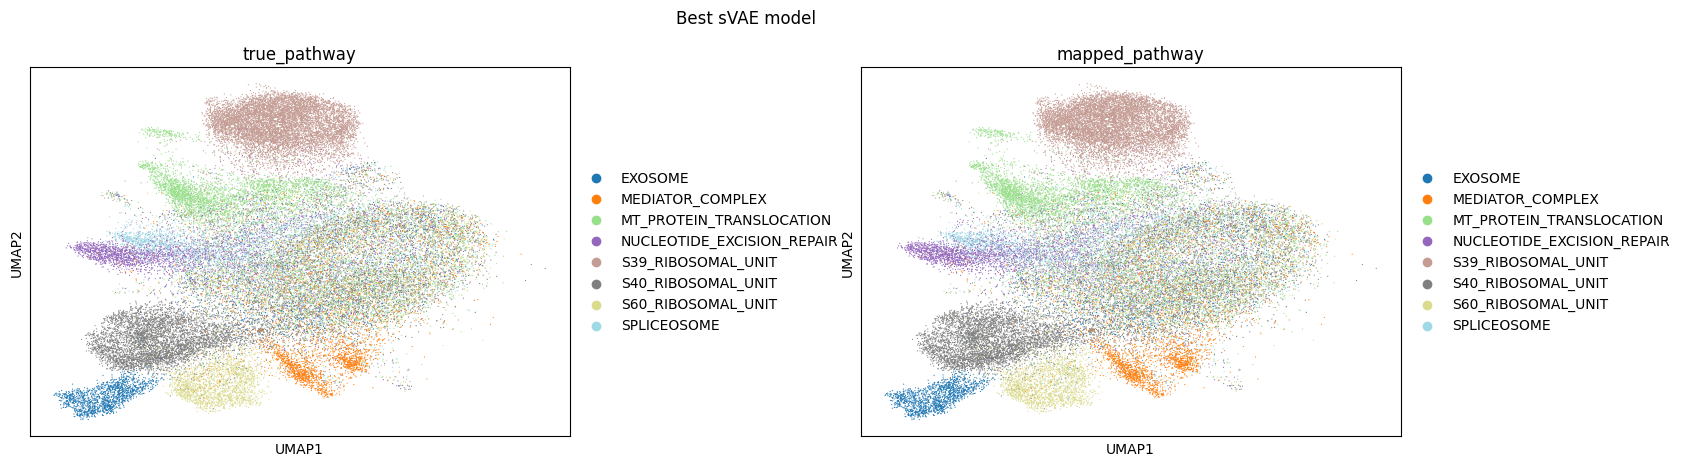


Generating figure for best cVAE model


/var/tmp/ipykernel_3570/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/cVAE_best_umap.png


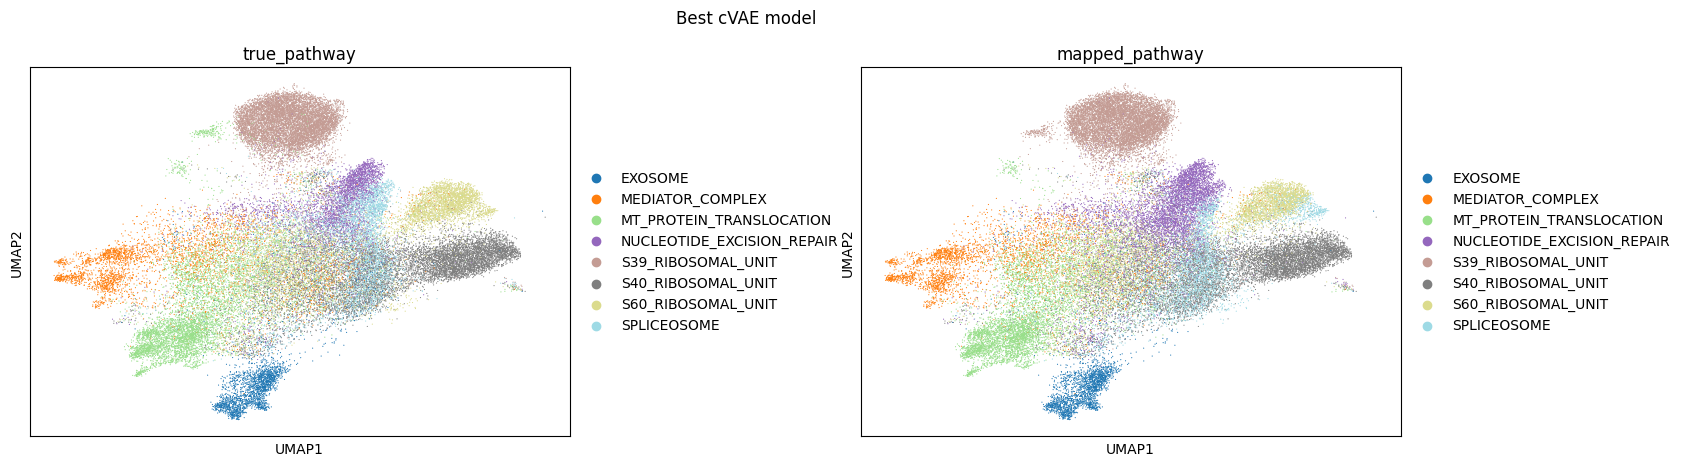


Generating figure for best contrastiveVI model


/var/tmp/ipykernel_3570/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/contrastiveVI_best_umap.png


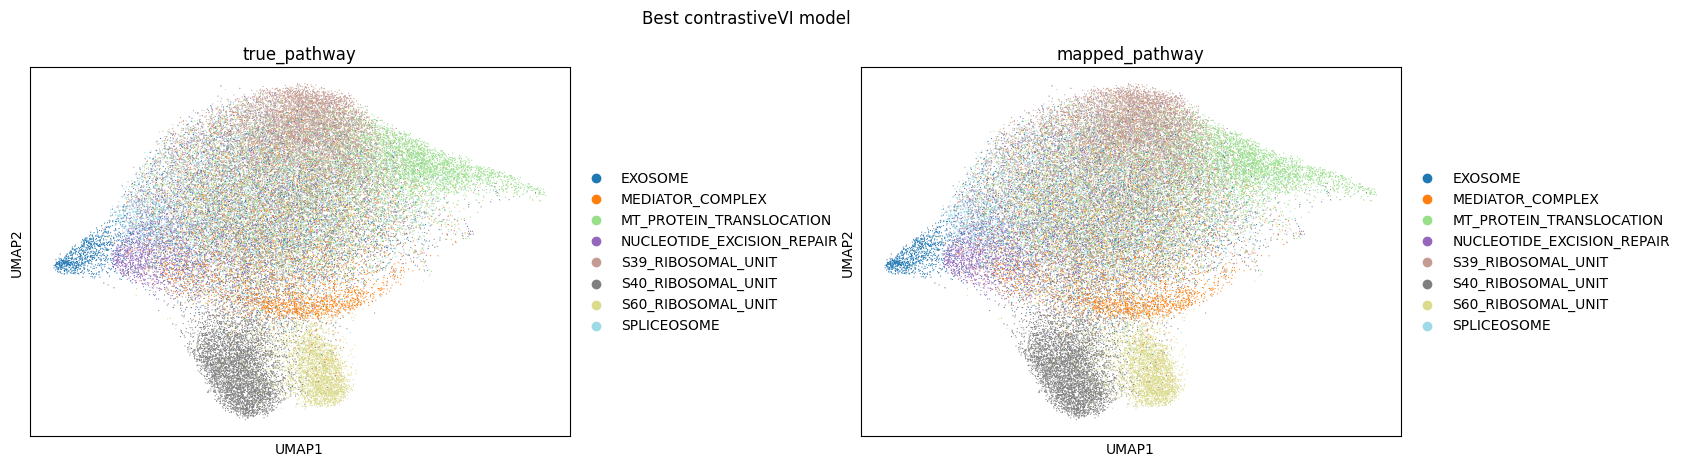


Generating figure for best scgen model


/var/tmp/ipykernel_3570/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/scgen_best_umap.png


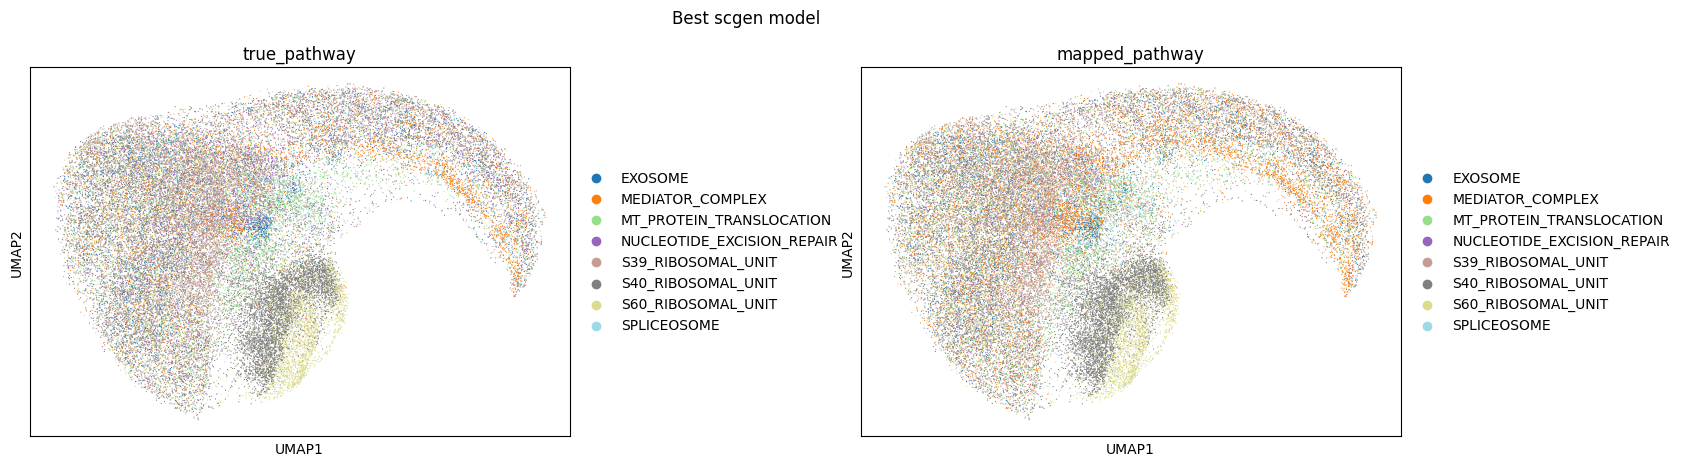

In [14]:
p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

for method_name, model in best_run_model.items():
    print(f"\n{'='*60}\nGenerating figure for best {method_name} model\n{'='*60}")

    # Re-eval the best model for this method
    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)

    # UMAP on non-NTC cells
    sub = data[data.obs[p_key] != NTC].copy()
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)

    # Cluster z_corr on pathway genes
    z_corr  = np.asarray(data.uns['results']['z_corr'])
    z_perts = np.asarray(data.uns['results']['z_perts'])

    pert_to_idx = {name: i for i, name in enumerate(z_perts)}
    valid_genes = [g for g in all_genes_filtered if g in pert_to_idx]
    gene_ids    = [pert_to_idx[g] for g in valid_genes]

    cov_subset = z_corr[np.ix_(gene_ids, gene_ids)]
    cov_subset = np.clip(cov_subset, -1.0, 1.0)
    cov_subset = 0.5 * (cov_subset + cov_subset.T)
    np.fill_diagonal(cov_subset, 1.0)

    groups = slk.tl.cluster_rho(data, t=N_CLUSTERS, rho_corr=cov_subset, criterion='maxclust', show=False)

    # Hungarian alignment of cluster → pathway labels
    clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': groups})
    pw_df = pathway_df_indexed.loc[pathway_df_indexed.index.isin(valid_genes)].reset_index()
    if 'gene' not in pw_df.columns:
        pw_df = pw_df.rename(columns={pathway_df_indexed.index.name or 'index': 'gene'})

    df_align  = pd.merge(clusters_df, pw_df, on='gene', how='inner')
    y_true    = df_align['pathway'].astype(str).values
    y_pred    = df_align['cluster'].astype(str).values
    true_lbl  = np.unique(y_true)
    pred_lbl  = np.unique(y_pred)

    C_mat = (
        pd.crosstab(df_align['pathway'].astype(str), df_align['cluster'].astype(str))
        .reindex(index=true_lbl, columns=pred_lbl, fill_value=0)
    )
    row_ind, col_ind = linear_sum_assignment(C_mat.values.max() - C_mat.values)
    mapping = {pred_lbl[j]: true_lbl[i] for i, j in zip(row_ind, col_ind)}
    df_align['mapped_pathway'] = [mapping.get(str(cl)) for cl in y_pred]

    # Subset z_sub to clustered genes and attach pathway labels
    clustered_genes = df_align['gene'].unique()
    z_sub = sub[sub.obs[p_key].isin(clustered_genes)].copy()

    gene_to_true   = dict(zip(df_align['gene'], df_align['pathway']))
    gene_to_mapped = dict(zip(df_align['gene'], df_align['mapped_pathway']))
    z_sub.obs['true_pathway']   = z_sub.obs[p_key].map(gene_to_true)
    z_sub.obs['mapped_pathway'] = z_sub.obs[p_key].map(gene_to_mapped)
    z_sub = z_sub[z_sub.obs['mapped_pathway'].notna()].copy()

    # Shared categorical palette across both columns
    all_cats  = pd.Index(np.unique(
        list(z_sub.obs['true_pathway'].dropna().unique()) +
        list(z_sub.obs['mapped_pathway'].dropna().unique())
    ).astype(str))
    cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
    z_sub.obs['true_pathway']   = z_sub.obs['true_pathway'].astype('string').astype(cat_dtype)
    z_sub.obs['mapped_pathway'] = z_sub.obs['mapped_pathway'].astype('string').astype(cat_dtype)

    cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))
    shared_palette = {cat: to_hex(cmap_col(i)) for i, cat in enumerate(all_cats)}
    z_sub.uns['true_pathway_colors']   = [shared_palette[c] for c in z_sub.obs['true_pathway'].cat.categories]
    z_sub.uns['mapped_pathway_colors'] = [shared_palette[c] for c in z_sub.obs['mapped_pathway'].cat.categories]

    # Plot and save
    fig = sc.pl.umap(
        z_sub,
        color=['true_pathway', 'mapped_pathway'],
        wspace=0.4,
        show=False,
        return_fig=True,
    )
    fig.suptitle(f'Best {method_name} model', y=1.02, fontsize=12)
    save_path = f'{RESULTS_DIR}/figures/{method_name}_best_umap.png'
    fig.savefig(save_path, bbox_inches='tight')
    print(f"  Saved → {save_path}")
    plt.show()